<a href="https://colab.research.google.com/github/davidsjohnson/wise24_xai_ac/blob/main/notebooks/tutorial_image_xai_task1_faus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explaining Facial Expression Recognition
# Notebook 1:  XAI for Affective Computing (SoSe2024)

In this notebook you will attempt to generate explanations for predictions of an XGBoost facial expression recognition (FER) model trained with tabular (structured) data extracted from images using a subset of the [AffectNet dataset](http://mohammadmahoor.com/affectnet/). AffectNet is an image dataset of facial expressions in the wild, and is labeled with 8 facial expression categories: **Neutral, Happy, Sad, Surprise, Fear, Disgust, Anger, and Contempt**. (Have a look at the paper for more details https://arxiv.org/abs/1708.03985).

More information will be provided in the tutorial. This is meant to get you familar with the dataset and models being used.


To use this notebook, please make sure to go step by step through each of the cells review the code and comments along the way.


***NOTE**: If using Google Colab, you can use a CPU only runtime as a GPU will not accelerate the XGBoost model.*

## Notebook Setup

Make sure to uncomment code based on if you are running locally or via Google Colab

In [1]:
## uncomment and run this cell to use Google Colab
!git clone https://github.com/davidsjohnson/wise24_xai_ac.git
# fix xgboost incompatiblity issue
%pip uninstall -y -q scikit-learn
%pip install -q scikit-learn==1.5.2

Cloning into 'wise24_xai_ac'...
remote: Enumerating objects: 491, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 491 (delta 15), reused 17 (delta 5), pack-reused 460 (from 1)
Receiving objects: 100% (491/491), 102.08 MiB | 11.64 MiB/s, done.
Resolving deltas: 100% (75/75), done.
Updating files: 100% (398/398), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 33.4 MB/s eta 0:00:00


In [2]:
import sys
import os
# sys.path.append(os.path.realpath('../'))  # uncomment this line if you are running this notebook locally
sys.path.append(os.path.realpath('wise24_xai_ac')) # uncomment this line if you are running this notebook on Google Colab

In [3]:
from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from scipy.stats import randint, uniform

import torch
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets, transforms
import torch.nn.functional as F
import torch.nn as nn

import seaborn as sns
import matplotlib.pyplot as plt

from skimage import io

import utils
import img_utils
import models
import evaluate

In [4]:
colab = True # change to False if running locally
base_dir = Path('../data/') if not colab else Path('wise24_xai_ac/data/')

## Data Loading

### Loading Images and Action Units

In the next cell, you will load csv files that contain extracted actions units and paths to the corresponding images.  

In [5]:

# Full data from training and evaluation
train_csv = base_dir / 'affectnet_aus/train_aus.csv'
val_csv = base_dir / 'affectnet_aus/val_aus.csv'

# load training and validation data as pandas dataframes
# action units extracted from the AffectNet dataset via OpenFace
df_train = pd.read_csv(train_csv)
df_val = pd.read_csv(val_csv)

# smaller dataset for explanations
xai_csv = base_dir / 'affectnet_aus/eval_aus.csv'
df_xai = pd.read_csv(xai_csv)
df_xai['image'] = df_xai['image'].str.replace('../data', str(base_dir))

# get only the columns storing action units from the dataframe
# there are also facial landmarks and other features in the dataset could be useful
# but we igore them for now and focus on action units
feature_names = [col for col in df_val.columns if col.startswith('AU')]
categorical_features = [feat for feat in feature_names if '_c' in feat]
categorical_idxs = [i for i, feat in enumerate(feature_names) if '_c' in feat]

# setup categorical features for XGBoost
for feat in categorical_features:
    df_train[feat] = df_train[feat].astype('category')
    df_val[feat] = df_val[feat].astype('category')

# get the class labels
class_names = ['Neutral', 'Happy', 'Sad', 'Surprise', 'Fear', 'Disgust', 'Anger', 'Contempt']  # same class labels as before

# Gets all images from folder used for XAI tasks
images = [io.imread(f) for f in df_xai.image]

Here is a feature name map to make AUs values easier to Read in Shap Plots

In [6]:
# Mapping of Action Units (AUs) to their names
AU_MAP = {
    "AU01": "Inner Brow Raiser",
    "AU02": "Outer Brow Raiser",
    "AU04": "Brow Lowerer",
    "AU05": "Upper Lid Raiser",
    "AU06": "Cheek Raiser",
    "AU07": "Lid Tightener",
    "AU09": "Nose Wrinkler",
    "AU10": "Upper Lip Raiser",
    "AU12": "Lip Corner Puller",
    "AU14": "Dimpler",
    "AU15": "Lip Corner Depressor",
    "AU17": "Chin Raiser",
    "AU20": "Lip Stretcher",
    "AU23": "Lip Tightener",
    "AU25": "Lips Part",
    "AU26": "Jaw Drop",
    "AU28": "Lip Suck",
    "AU45": "Blink",
}

# Generate mappings for both 'r' (regression) and 'c' (classification) versions
AU_FEATURE_MAP = {f"{au}_r": f"{au} - {name} - R" for au, name in AU_MAP.items()}
AU_FEATURE_MAP.update({f"{au}_c": f"{au} - {name} - C" for au, name in AU_MAP.items()})

# Print the mapping
print(AU_FEATURE_MAP)

{'AU01_r': 'AU01 - Inner Brow Raiser - R', 'AU02_r': 'AU02 - Outer Brow Raiser - R', 'AU04_r': 'AU04 - Brow Lowerer - R', 'AU05_r': 'AU05 - Upper Lid Raiser - R', 'AU06_r': 'AU06 - Cheek Raiser - R', 'AU07_r': 'AU07 - Lid Tightener - R', 'AU09_r': 'AU09 - Nose Wrinkler - R', 'AU10_r': 'AU10 - Upper Lip Raiser - R', 'AU12_r': 'AU12 - Lip Corner Puller - R', 'AU14_r': 'AU14 - Dimpler - R', 'AU15_r': 'AU15 - Lip Corner Depressor - R', 'AU17_r': 'AU17 - Chin Raiser - R', 'AU20_r': 'AU20 - Lip Stretcher - R', 'AU23_r': 'AU23 - Lip Tightener - R', 'AU25_r': 'AU25 - Lips Part - R', 'AU26_r': 'AU26 - Jaw Drop - R', 'AU28_r': 'AU28 - Lip Suck - R', 'AU45_r': 'AU45 - Blink - R', 'AU01_c': 'AU01 - Inner Brow Raiser - C', 'AU02_c': 'AU02 - Outer Brow Raiser - C', 'AU04_c': 'AU04 - Brow Lowerer - C', 'AU05_c': 'AU05 - Upper Lid Raiser - C', 'AU06_c': 'AU06 - Cheek Raiser - C', 'AU07_c': 'AU07 - Lid Tightener - C', 'AU09_c': 'AU09 - Nose Wrinkler - C', 'AU10_c': 'AU10 - Upper Lip Raiser - C', 'AU12_

## XAI for Tabular Data

In this part, we will generate explanations for the XGBoost model trained using a dataset of Facial Action Units (as described in the notebook introduction).  

First, let's load the data and the trained models. Then we will evaluate the model peformance, before we start with the explanations.

In [7]:
from xgboost import XGBClassifier

### Setup the Datasets

In [8]:
X_train = df_train[feature_names]
y_train = df_train['class']
X_test = df_val[feature_names]
y_test = df_val['class']

X_xai = df_xai[feature_names]
y_xai = df_xai['class']

print('Training data shape:', X_train.shape, y_train.shape)
print('Test data shape:', X_test.shape, y_test.shape)
print('XAI data shape:', X_xai.shape, y_xai.shape)

Training data shape: (36685, 35) (36685,)
Test data shape: (3908, 35) (3908,)
XAI data shape: (80, 35) (80,)


### Train the Model

Now let's train the XGBoost Model on the split dataset. The accuracy of the model in the training data should be around $92\%$

In [9]:
# # Train model from scratch
random_state = 10
clf = XGBClassifier(booster='gbtree', enable_categorical=True, max_depth=15, eta=0.1, reg_lambda=30, random_state=random_state)
clf.fit(X_train, y_train)
clf.score(X_train, y_train)

0.9220934987051929

### Evaluate the Model

Now we will evaluate it on the test dataset. Unfortunately, the accuracy is only $44\%$ but this is still well above chance guessing which would be $1 / 8 * 100 = 12.5\%$ accuracy (since there are 8 total classes)

In [10]:
# get model predictions
y_test_preds = clf.predict(X_test)
y_test_true = y_test

# eval results
print(classification_report(y_test_true, y_test_preds, target_names=class_names))

              precision    recall  f1-score   support

     Neutral       0.34      0.41      0.37       485
       Happy       0.57      0.68      0.62       488
         Sad       0.39      0.43      0.41       490
    Surprise       0.44      0.43      0.44       488
        Fear       0.48      0.46      0.47       487
     Disgust       0.50      0.35      0.41       493
       Anger       0.36      0.42      0.39       482
    Contempt       0.44      0.32      0.37       495

    accuracy                           0.44      3908
   macro avg       0.44      0.44      0.43      3908
weighted avg       0.44      0.44      0.43      3908



We can also review the confusion matrix to see where the model makes its mistakes

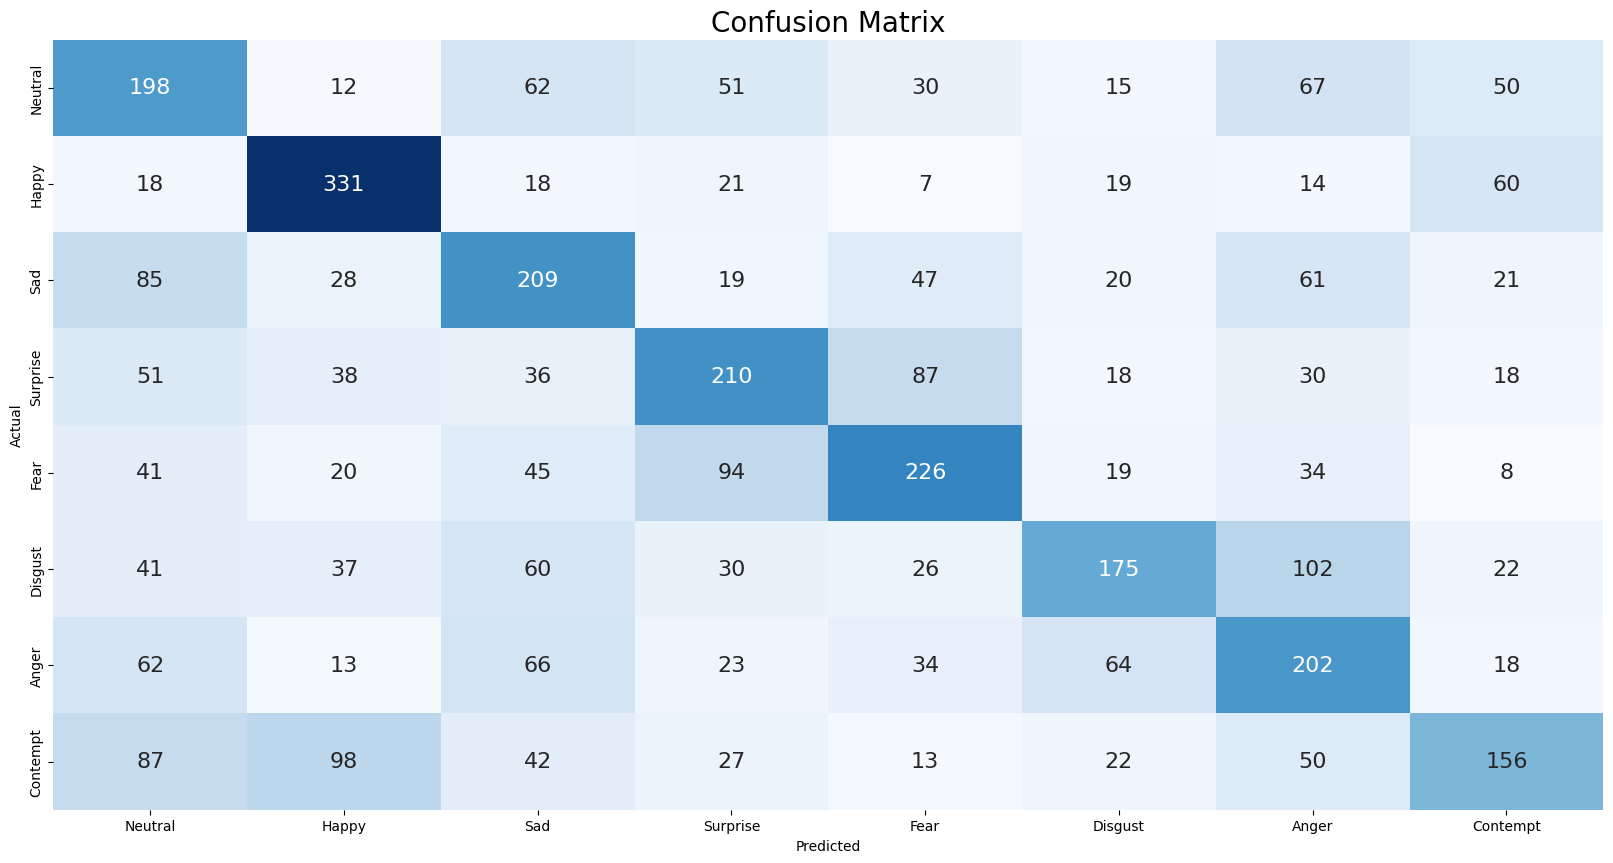

In [11]:
cm_data = confusion_matrix(y_test_true, y_test_preds)
cm = pd.DataFrame(cm_data, columns=class_names, index=class_names)
cm.index.name = 'Actual'
cm.columns.name = 'Predicted'
plt.figure(figsize = (20,10))
plt.title('Confusion Matrix', fontsize = 20)
sns.set(font_scale=1.2)
ax = sns.heatmap(cm, cbar=False, cmap="Blues", annot=True, annot_kws={"size": 16}, fmt='g')

### Setup XAI dataset and Predictions

In [12]:
# Evaluate model on XAI data
y_xai_preds = clf.predict(X_xai)
y_xai_true = y_xai

df_xai['xgb_pred'] = y_xai_preds

print(classification_report(y_xai_true, y_xai_preds, target_names=class_names))

              precision    recall  f1-score   support

     Neutral       0.12      0.20      0.15        10
       Happy       0.55      0.60      0.57        10
         Sad       0.45      0.50      0.48        10
    Surprise       0.62      0.50      0.56        10
        Fear       0.60      0.60      0.60        10
     Disgust       0.50      0.40      0.44        10
       Anger       0.10      0.10      0.10        10
    Contempt       0.50      0.30      0.38        10

    accuracy                           0.40        80
   macro avg       0.43      0.40      0.41        80
weighted avg       0.43      0.40      0.41        80



## Generate Explanations

In this notebook you will generate both global and local explanations for the XGBoost model using SHAP. Review the [SHAP Documentation for Details](https://shap.readthedocs.io/en/latest/index.html)

In [13]:
# uncomment if using Google Colab
%pip install -q shap

In [14]:
import shap

### Task 1 - Generate Global Explanations

**Task 1.1:** Using SHAP to generate explainations for the `X_xai` dataset.  

**Task 1.2:**  Then plot global explanations for each class using a `summary_plot` (or a `beeswarm` plot). The XGBoost tutorial in the documentation is a good place to start.  Keep in mind that Facial Expression Recognition is a multi class (8 emotion) problem rather than a binary problem as in the tutorial.


**Task 1.3:** Then review the [documentation for the different plot type available](https://shap.readthedocs.io/en/latest/api.html#plots), and try generating other plots for global explanations of the model.

**Task 1.4:** Answer Question 1 below


(Note:  It will help make the plots easier to understand if you update the feature names to include the full AU name.  So after generating your explanations, use `AU_FEATURE_MAP` to update the feature names in the `Explanations` object

In [15]:
###### Enter your Code Here ######
##################################



#### Question 1

Provide one or two paragraphns on your findings.

Here some some ideas to reflect on but you're not limited to these.
  

*   How do you interpret these results?
*   What interesting insights did you find?  
*   What are some limitations in this approach?
*   Are there any insights on why this model performs poorly? If so, what? If not, how could you use global insights to find this out?

### Task 2 - Generate Local Explanations

In this task you will generate local explanations with Shap

**Task 2.1:** Select 6 image that you want to gain explanations for. Choose 3 correct and 3 incorrect explanations

**Task 2.2:** Generate Local Explanations for each image using a Waterfall plot. For each incorrect image, make sure to plot both the explanation for the prediction and the true emotion. When displaying SHAP plot, also plot the original image along side it

**Task 2.3:** Generate local explanations using another plot from the SHAP library.

**Task 2.4:** Answer Question 2 below.

In [16]:
###### Enter your Code Here ######
##################################



**Preview the Dataset with Predictions**

The code below will display images from the XAI dataset.
- Try changing value of `start` to get a new set of images (there are 10 images for each class; for example, the class happy will be at indexes 10-19)
- Search through the images to find some that might be interesting to Explain

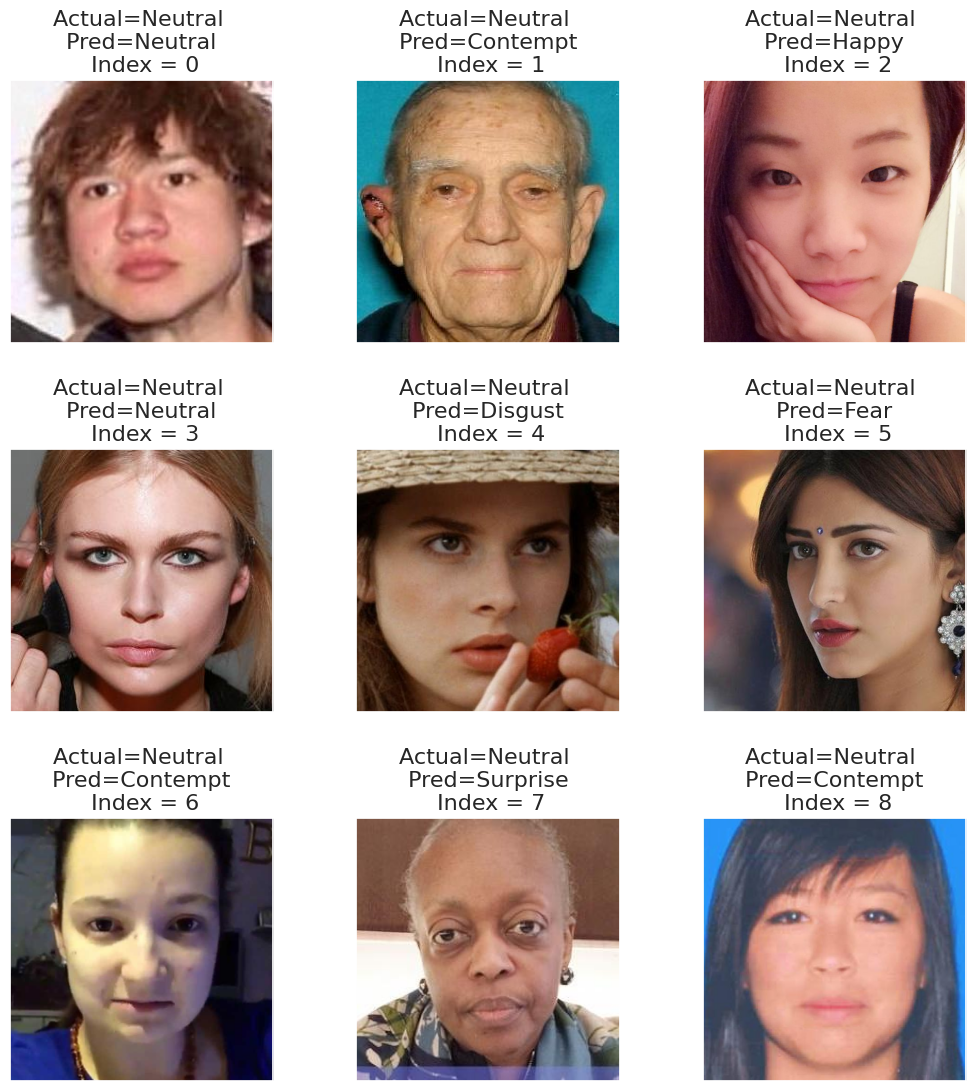

In [17]:
start=0
img_utils.display_nine_images(images, df_xai['class'], df_xai['xgb_pred'], start)

In [18]:
###### Enter your Code Here ######
##################################

img_idxs_corr = []
img_idxs_incorr = []

#### Question 2

Do these explanations help you better understand why a decision was made?  Why or why not?  What would be a better way to understand the logic behind the model decision?